# 06. Первый итог до признаков курсора

Теперь есть несколько моделей и оценки каждой куки на трёх временных проверках. Посмотрим, ошибаются ли лучшие варианты одинаково, и проверим несколько простых смесей. После выбора снова обучим нужные модели на исходных данных и сохраним этот ранний вариант отдельно в `output/previous_rank_submission.csv`.

Проверка качества здесь только по train. Метки скрытого test нам неизвестны. Ноутбук можно открыть из корня проекта или из папки `notebooks/`. Python 3.12, версии библиотек есть в `requirements.txt`, random seed зафиксирован в коде

In [1]:
# Открой ноутбук из корня проекта или из папки notebooks.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "data" / "train.csv").is_file():
    raise FileNotFoundError("Не найдена папка data. Открой ноутбук из проекта.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from utils.blending import mean_percentile_rank
from utils.features import build_features
from utils.journeys import build_journey_features
from utils.metric import precision_at_recall, pr_curve

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 125, "font.size": 10})
print("Python:", sys.version.split()[0])

Python: 3.12.10


## Сводим проверки в одну таблицу

Предыдущие ноутбуки уже сохранили предсказания на тех днях, которые модели не видели при обучении. Соединяем таблицы по `cookie_id`, отрезку и настоящей метке. Это нужно только для выбора подхода. Итоговый файл ниже будет построен из сырых данных, а не из этих промежуточных CSV

In [2]:
keys = ["cookie_id", "fold", "target"]
old = pd.read_csv("output/model_validation_scores.csv")
new = pd.read_csv("output/feature_validation_scores.csv")
journey = pd.read_csv("output/journey_validation_scores.csv")

for frame in [old, new, journey]:
    assert not frame.duplicated(keys).any()
    assert frame.cookie_id.is_unique
    assert len(frame) == len(old)

validation = old[keys + [
    "baseline_logreg", "rich_logreg", "random_forest", "catboost", "catboost_no_ua"
]].merge(new[keys + ["routes"]], on=keys, validate="one_to_one").merge(
    journey[keys + ["context_pruned"]], on=keys, validate="one_to_one"
)
assert len(validation) == len(old)
assert validation.drop(columns=keys).notna().all().all()
folds = ["11–13 апреля", "14–16 апреля", "17–19 апреля"]
print(f"Проверочных кук: {len(validation):,}")
print("Ботов по отрезкам:", validation.groupby("fold").target.sum().reindex(folds).to_dict())

Проверочных кук: 6,874
Ботов по отрезкам: {'11–13 апреля': 199, '14–16 апреля': 195, '17–19 апреля': 160}


In [3]:
model_names = {
    "baseline_logreg": "Логрег, 5 признаков",
    "rich_logreg": "Логрег, 50 признаков",
    "random_forest": "Случайный лес",
    "catboost": "CatBoost с User-Agent",
    "catboost_no_ua": "CatBoost без User-Agent",
    "routes": "CatBoost с маршрутами",
    "context_pruned": "CatBoost с контекстом",
}
rows = []
for column, label in model_names.items():
    row = {"модель": label}
    for fold_name, part in validation.groupby("fold"):
        row[fold_name] = precision_at_recall(part.target, part[column])
    row["среднее"] = np.mean([row[name] for name in folds])
    rows.append(row)
model_table = pd.DataFrame(rows).set_index("модель")
display(model_table[folds + ["среднее"]].round(3))

,11–13 апреля,14–16 апреля,17–19 апреля,среднее
модель,,,,
"Логрег, 5 признаков",0.159,0.149,0.134,0.147
"Логрег, 50 признаков",0.323,0.387,0.412,0.374
Случайный лес,0.304,0.423,0.511,0.413
CatBoost с User-Agent,0.491,0.529,0.521,0.514
CatBoost без User-Agent,0.461,0.544,0.560,0.521
CatBoost с маршрутами,0.484,0.509,0.596,0.530
CatBoost с контекстом,0.486,0.541,0.580,0.536


Среди отдельных моделей на последних днях лучше CatBoost с маршрутами: 0,596. У версии с контекстом среднее чуть выше, но она сильнее проседает на последнем отрезке. Логистическая регрессия остаётся понятной и быстрой точкой отсчёта, однако по основной метрике уступает деревьям. Теперь важно понять, есть ли у трёх CatBoost разные ошибки

## Насколько совпадают ошибки

Для каждой модели найдём на каждом отрезке тот порог, при котором достигается её лучший Precision с Recall не ниже 70%. Порог здесь нужен только для разбора ошибок; в файл ответа он не попадёт. Равные значения `score` обрабатываем целой группой, как в официальной метрике

In [4]:
def marked_at_best_threshold(target, score):
    target = np.asarray(target, dtype=int)
    score = np.asarray(score, dtype=float)
    order = np.argsort(-score, kind="mergesort")
    sorted_target, sorted_score = target[order], score[order]
    group_ends = np.flatnonzero(np.r_[sorted_score[1:] != sorted_score[:-1], True])
    true_positives = np.cumsum(sorted_target)[group_ends]
    precision = true_positives / (group_ends + 1)
    recall = true_positives / target.sum()
    allowed = np.flatnonzero(recall >= .70)
    chosen = allowed[np.argmax(precision[allowed])]
    marked = score >= sorted_score[group_ends[chosen]]
    assert np.isclose(target[marked].mean(), precision_at_recall(target, score))
    return marked

comparison = []
for fold_name, part in validation.groupby("fold"):
    target = part.target.to_numpy(dtype=bool)
    routes = marked_at_best_threshold(target, part.routes)
    context = marked_at_best_threshold(target, part.context_pruned)
    comparison.append({
        "отрезок": fold_name,
        "ботов нашли обе": int((target & routes & context).sum()),
        "только маршруты": int((target & routes & ~context).sum()),
        "только контекст": int((target & context & ~routes).sum()),
        "не нашли обе": int((target & ~routes & ~context).sum()),
        "корреляция score": part.routes.corr(part.context_pruned, method="spearman"),
    })
display(pd.DataFrame(comparison).set_index("отрезок").reindex(folds).round(3))

,ботов нашли обе,только маршруты,только контекст,не нашли обе,корреляция score
отрезок,,,,,
11–13 апреля,136,4,4,55,0.935
14–16 апреля,132,5,6,52,0.932
17–19 апреля,109,3,3,45,0.945


Оценки двух новых CatBoost сильно похожи: ранговая корреляция около 0,93–0,95. На каждом отрезке один вариант находит лишь несколько ботов, которых не отметил другой. Смешивание может помочь прежде всего лучше расставить куки около порога и отсеять лишние ложные срабатывания. Проверим это напрямую по метрике

## Несколько простых смесей

Проверяем равные веса, без подбора коэффициентов по этим трём отрезкам. Смешиваем три версии CatBoost без User-Agent: старую, с маршрутами и с контекстом. Для сравнения покажем смесь двух версий и среднее рангов. Последний вариант зависит от всей партии кук: оценка одной куки изменится, если изменится состав партии

,11–13 апреля,14–16 апреля,17–19 апреля,среднее
вариант,,,,
Старый CatBoost,0.461,0.544,0.560,0.521
CatBoost с маршрутами,0.484,0.509,0.596,0.530
CatBoost с контекстом,0.486,0.541,0.580,0.536
Среднее двух новых,0.509,0.502,0.602,0.538
Среднее трёх score,0.538,0.531,0.605,0.558
Среднее трёх рангов,0.524,0.552,0.622,0.566


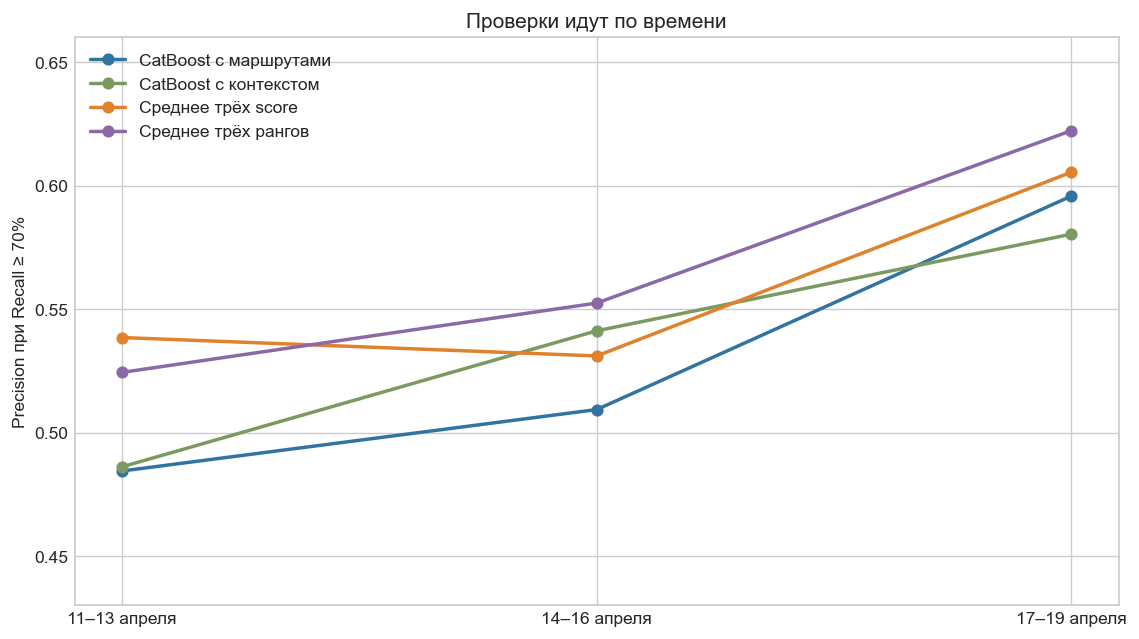

In [5]:
validation["pair_mean"] = (validation.routes + validation.context_pruned) / 2
validation["three_mean"] = (
    validation.catboost_no_ua + validation.routes + validation.context_pruned
) / 3
rank_columns = ["catboost_no_ua", "routes", "context_pruned"]
validation["three_rank_mean"] = (
    validation.groupby("fold")[rank_columns].rank(pct=True).mean(axis=1)
)

candidates = {
    "catboost_no_ua": "Старый CatBoost",
    "routes": "CatBoost с маршрутами",
    "context_pruned": "CatBoost с контекстом",
    "pair_mean": "Среднее двух новых",
    "three_mean": "Среднее трёх score",
    "three_rank_mean": "Среднее трёх рангов",
}
blend_rows = []
for column, label in candidates.items():
    row = {"вариант": label}
    for fold_name, part in validation.groupby("fold"):
        row[fold_name] = precision_at_recall(part.target, part[column])
    row["среднее"] = np.mean([row[name] for name in folds])
    blend_rows.append(row)
blend_table = pd.DataFrame(blend_rows).set_index("вариант")
display(blend_table[folds + ["среднее"]].round(3))

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
colors = {"CatBoost с маршрутами": "#3274A1", "CatBoost с контекстом": "#7A9A61",
          "Среднее трёх score": "#E1812C", "Среднее трёх рангов": "#8B69A6"}
for label, color in colors.items():
    ax.plot(folds, blend_table.loc[label, folds].to_numpy(dtype=float), marker="o",
            linewidth=2, label=label, color=color)
ax.set(ylabel="Precision при Recall ≥ 70%", title="Проверки идут по времени", ylim=(.43, .66))
ax.legend()
plt.show()

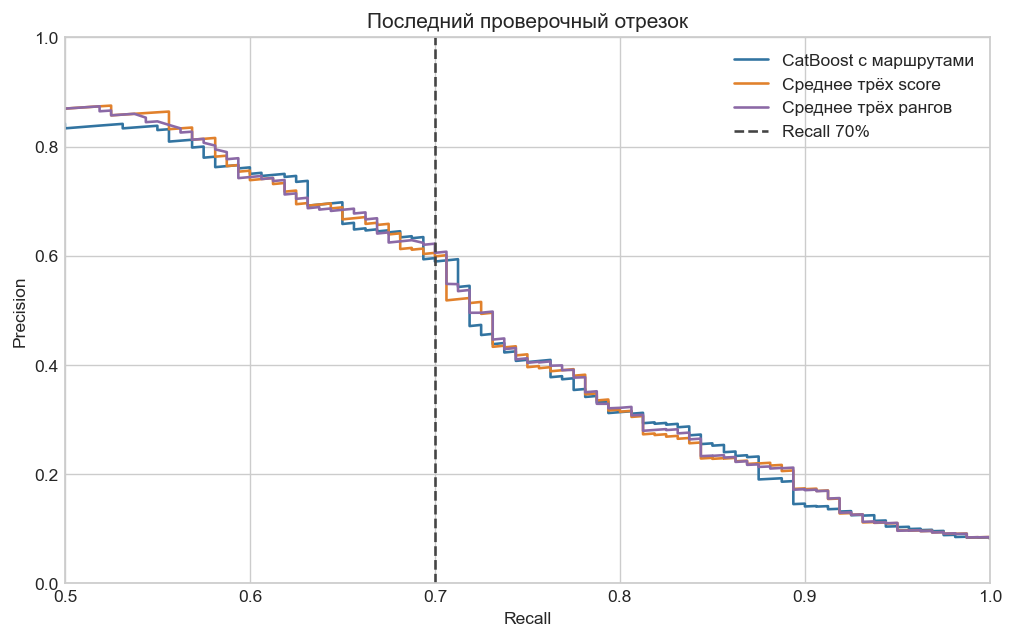

In [6]:
last = validation.loc[validation.fold.eq(folds[-1])]
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
for column, label, color in [
    ("routes", "CatBoost с маршрутами", "#3274A1"),
    ("three_mean", "Среднее трёх score", "#E1812C"),
    ("three_rank_mean", "Среднее трёх рангов", "#8B69A6"),
]:
    precision, recall = pr_curve(last.target, last[column])
    ax.plot(recall, precision, label=label, color=color)
ax.axvline(.70, linestyle="--", color="#444444", label="Recall 70%")
ax.set(xlabel="Recall", ylabel="Precision", xlim=(.5, 1), ylim=(0, 1),
       title="Последний проверочный отрезок")
ax.legend()
plt.show()

Среднее исходных `score` улучшило CatBoost с маршрутами на всех трёх отрезках. Среднее рангов обошло среднее `score` на двух поздних проверках и по общему результату: 0,566 против 0,558. На первой проверке ранги хуже: 0,524 против 0,538. Разница небольшая, а порядок кук у смесей почти одинаковый. Победу на скрытом test это не гарантирует.

На этом этапе выбрали **среднее рангов**. Проверка оценивает порядок кук, и на наших временных отрезках этот способ оказался чуть сильнее. Каждая из трёх моделей сортирует куки внутри test; мы переводим места в числа от 0 до 1 и усредняем. Равные оценки получают одинаковый ранг. Весов по валидации не подбирали.

У такого `score` есть особенность: он зависит от состава партии. Если добавить новые куки, места прежних могут сдвинуться. Для сервиса, который отвечает на один запрос за раз, способ оценки пришлось бы выбирать отдельно. Здесь готовим один файл для фиксированного test. Как и раньше, нужно обучить три модели и посчитать контекстные признаки. По этому небольшому набору нельзя обещать скорость в проде; требования к ней в условии не заданы

## Получаем ответ заново из исходных файлов

Ниже нет чтения промежуточных предсказаний. Загружаем train, test и события, оставляем для каждой куки только её суточное окно, считаем признаки, обучаем три CatBoost на всём train. Для сравнения с новыми вариантами сохраняем только `cookie_id` и среднее трёх процентильных рангов

In [7]:
root = Path("data")
train = pd.read_csv(root / "train.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv(root / "test.csv", parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv(root / "events.csv.gz", parse_dates=["event_ts"])

start = perf_counter()
features, groups, n_inside = build_features(train, test, events)
journey_features, journey_groups = build_journey_features(train, test, events)
features = features.merge(
    journey_features.drop(columns="split"), on="cookie_id", how="left", validate="one_to_one"
)
feature_seconds = perf_counter() - start
X_train = features.iloc[:len(train)].reset_index(drop=True)
X_test = features.iloc[len(train):].reset_index(drop=True)
y = train.target.to_numpy()

base_columns = [column for column in groups["base"]
                if column not in {"headless_ua", "automation_ua", "ua_count"}]
route_columns = base_columns + groups["routes"]
context_columns = [column for column in journey_groups["context"]
                   if column != "seller_switch_share"]
final_columns = {
    "base": base_columns,
    "routes": route_columns,
    "context": route_columns + context_columns,
}
assert X_train.cookie_id.equals(train.cookie_id)
assert X_test.cookie_id.equals(test.cookie_id)
assert all(len(columns) == len(set(columns)) for columns in final_columns.values())
assert all(not set(columns) & {"cookie_id", "target", "window_start_ts"}
           for columns in final_columns.values())
print(f"Событий внутри окон: {n_inside:,} | признаки посчитаны за {feature_seconds:.1f} с")

Событий внутри окон: 288,126 | признаки посчитаны за 5.9 с


In [8]:
def make_catboost():
    return CatBoostClassifier(
        iterations=600, depth=6, learning_rate=.05, l2_leaf_reg=5,
        loss_function="Logloss", verbose=False, random_seed=RANDOM_STATE,
        thread_count=4, allow_writing_files=False,
    )

scores = []
fit_seconds = {}
for name, columns in final_columns.items():
    model = make_catboost()
    start = perf_counter()
    model.fit(X_train[columns], y)
    fit_seconds[name] = perf_counter() - start
    scores.append(model.predict_proba(X_test[columns])[:, 1])
    print(f"{name}: обучение {fit_seconds[name]:.1f} с")

submission = pd.DataFrame({
    "cookie_id": test.cookie_id,
    "score": mean_percentile_rank(scores),
})
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
submission_path = output_dir / "previous_rank_submission.csv"
submission.to_csv(submission_path, index=False, float_format="%.10f")
print("Сохранён", submission_path)

base: обучение 1.3 с


routes: обучение 1.3 с


context: обучение 1.4 с
Сохранён output/previous_rank_submission.csv


## Проверяем файл

У `sample_submission.csv` порядок строк отличается от `test.csv`, поэтому сверяем набор ID, а не позицию каждой строки. В готовом ответе придерживаемся порядка `test.csv`. Проверяем две колонки, все куки, отсутствие дублей и диапазон оценок

Проверка прошла: 4,909 кук, score от 0.0004 до 0.9996


,cookie_id,score
0,ck_315fb710a0e371e7,0.002037
1,ck_a76ee3b3e3e522fd,0.756094
2,ck_94c9a4d382689e82,0.741495
3,ck_8eaf9509ad9462a0,0.058192
4,ck_9a88a5a989cb5bc6,0.508929


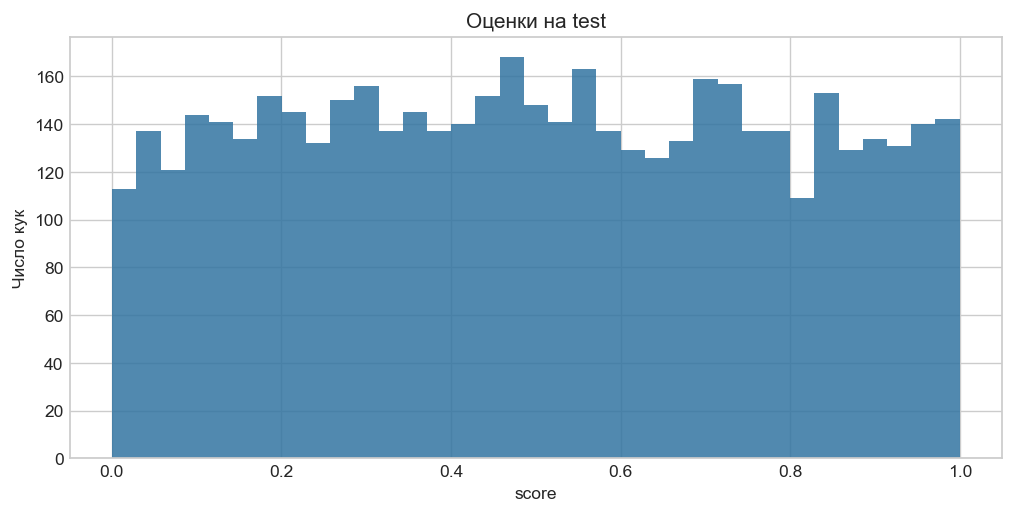

In [9]:
saved = pd.read_csv(submission_path)
sample = pd.read_csv(root / "sample_submission.csv")
assert saved.columns.tolist() == ["cookie_id", "score"]
assert len(saved) == len(test) == len(sample)
assert saved.cookie_id.is_unique
assert saved.cookie_id.equals(test.cookie_id)
assert set(saved.cookie_id) == set(sample.cookie_id)
assert saved.score.notna().all() and np.isfinite(saved.score).all()
assert saved.score.between(0, 1).all()
print(f"Проверка прошла: {len(saved):,} кук, score от {saved.score.min():.4f} до {saved.score.max():.4f}")
display(saved.head())

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.hist(saved.score, bins=35, color="#3274A1", alpha=.85)
ax.set(xlabel="score", ylabel="Число кук", title="Оценки на test")
plt.show()

## Что получилось

| Подход | Плюс | Ограничение |
| --- | --- | --- |
| Логистическая регрессия, 5 признаков | Быстрая и понятная точка отсчёта | Слишком мало информации о поведении, среднее P@R70 0,147 |
| Логистическая регрессия, 50 признаков | Простой способ проверить пользу новых агрегатов, среднее 0,374 | Не ловит сложные сочетания так хорошо, как деревья; часть признаков зависит от User-Agent |
| Случайный лес | Улавливает нелинейность, среднее 0,413 | Уступил CatBoost на всех трёх отрезках |
| CatBoost с User-Agent | Может использовать явные подсказки в строке браузера, среднее 0,514 | Строку легко подделать, на двух последних отрезках вариант без неё был лучше |
| CatBoost без User-Agent | Сильная и сравнительно простая база, среднее 0,522 | Ошибается на активных людях и новых типах ботов |
| CatBoost с маршрутами | Лучший отдельный вариант на последних днях, 0,596 | На среднем отрезке уступил старой версии; нужно считать последовательности |
| CatBoost с контекстом | Лучшее среднее среди отдельных моделей, 0,536 | На последних днях уступил маршрутам; часть признаков часто отсутствует |
| Среднее рангов трёх CatBoost | Лучший результат на наших проверках, среднее 0,566 | Нужно запускать три модели; оценка зависит от состава test, скрытый результат может отличаться |

Это офлайн-результат на куках из известных источников. `score` не стоит трактовать как откалиброванную вероятность. Даже при нужном Recall точность на последнем отрезке около 0,622: жёсткая блокировка по такому сигналу может задеть много людей. Реальное действие и его порог нужно выбирать отдельно, с проверкой влияния на пользователей. Этот ранний кандидат лежит в `output/previous_rank_submission.csv`. Дальше мы добавим признаки курсора и Word2Vec. Итоговый ответ из ноутбука 13 создаёт `run_solution.py` в `output/submission.csv`